# Fig 1.09
Hodgkin-Huxley model

In [1]:
using OrdinaryDiffEq
using ModelingToolkit
using Plots
Plots.default(linewidth=2)

Convenience functions

In [2]:
hil(x, k) = x / (x + k)
hil(x, k, n) = hil(x^n, k^n)
exprel(x) = x / expm1(x)

exprel (generic function with 1 method)

HH Neuron model

In [3]:
function build_hh(;name)
    @independent_variables t
    @parameters begin
        E_N = 55.0       ## Reversal potential of Na (mV)
        E_K = -72.0      ## Reversal potential of K (mV)
        E_LEAK = -49.0   ## Reversal potential of leaky channels (mV)
        G_N_BAR = 120.0  ## Max. Na channel conductance (mS/cm^2)
        G_K_BAR = 36.0   ## Max. K channel conductance (mS/cm^2)
        G_LEAK = 0.30    ## Max. leak channel conductance (mS/cm^2)
        C_M = 1.0        ## membrane capacitance (uF/cm^2))
        iStim(t) = 0.0   ## stimulation current
    end
    @variables begin
        mα(t)
        mβ(t)
        hα(t)
        hβ(t)
        nα(t)
        nβ(t)
        iNa(t)
        iK(t)
        iLeak(t)
        v(t) = -59.8977
        m(t) = 0.0536
        h(t) = 0.5925
        n(t) = 0.3192
    end

    D = Differential(t)

    eqs = [
        mα ~ exprel(-0.10 * (v + 35)),
        mβ ~ 4.0 * exp(-(v + 60) / 18.0),
        hα ~ 0.07 * exp(- ( v + 60) / 20),
        hβ ~ 1 / (exp(-(v+30)/10) + 1),
        nα ~ 0.1 * exprel(-0.1 * (v+50)),
        nβ ~ 0.125 * exp( -(v+60) / 80),
        iNa ~ G_N_BAR * (v - E_N) * (m^3) * h,
        iK  ~ G_K_BAR * (v - E_K) * (n^4),
        iLeak ~ G_LEAK * (v - E_LEAK),
        D(v) ~ -(iNa + iK + iLeak + iStim) / C_M,
        D(m) ~ -(mα + mβ) * m + mα,
        D(h) ~ -(hα + hβ) * h + hα,
        D(n) ~ -(nα + nβ) * n + nα,
    ]
    discrete_events = [[20] => [iStim ~ -6.6], [21] => [iStim ~ 0], [60] => [iStim ~ -6.9], [61] => [iStim ~ 0]]

    return ODESystem(eqs, t; name, discrete_events)
end

build_hh (generic function with 1 method)

In [4]:
tspan = (0.0, 100.0)
@mtkbuild sys = build_hh()
prob = ODEProblem(sys, [], tspan, []);
sol = solve(prob)

retcode: Success
Interpolation: 3rd order Hermite
t: 191-element Vector{Float64}:
   0.0
   0.0
   0.28649552814014345
   0.6282062598888134
   1.1292780059864103
   1.788539543713246
   2.7280332499045175
   3.8225722202572276
   4.8381191258330505
   5.700042620198738
   ⋮
  83.08516202284112
  84.68698057714978
  86.36486332963332
  87.94059887845873
  89.94173820482408
  92.62531703206089
  95.01785835817743
  97.77383021285664
 100.0
u: 191-element Vector{Vector{Float64}}:
 [-59.8977, 0.0536, 0.5925, 0.3192]
 [-59.8977, 0.0536, 0.5925, 0.3192]
 [-59.896772589630615, 0.053584781785332665, 0.592500685682472, 0.3192027439091019]
 [-59.896078417587496, 0.05358354985022893, 0.5925003853539793, 0.31920656870895786]
 [-59.895380703866564, 0.05358732070491404, 0.592498563192231, 0.3192127047916002]
 [-59.894827103417214, 0.05359154097918554, 0.5924946675523771, 0.3192210724000593]
 [-59.894615228409705, 0.05359428457937118, 0.5924881300109393, 0.31923235771422587]
 [-59.895058903433394, 0

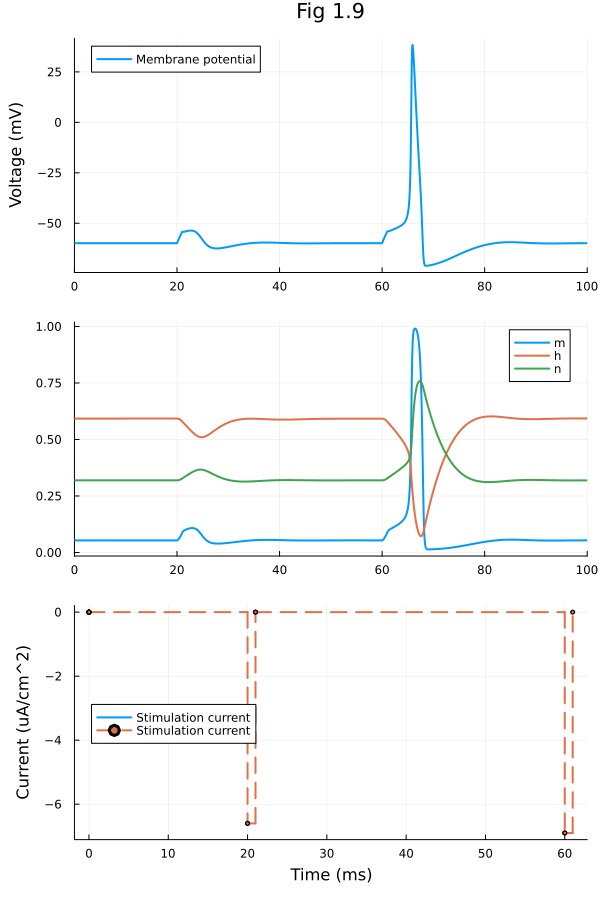

In [5]:
@unpack v, m, h, n, iStim = sys
p1 = plot(sol, idxs = v, ylabel="Voltage (mV)", xlabel="",  label="Membrane potential", title="Fig 1.9", legend=:topleft)
p2 = plot(sol, idxs = [m, h, n], xlabel="")
p3 = plot(sol, idxs = iStim, xlabel="Time (ms)", ylabel="Current (uA/cm^2)", label="Stimulation current", legend=:left)
plot(p1, p2, p3, layout=(3, 1), size=(600, 900), leftmargin=5*Plots.mm)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*